# Actividad de Estadística Inferencial en R: Costos en Salud

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Daniel-534/Astroestadistica/blob/main/ITM/Actividad_ITM_Estadistica_Inferencial_R.ipynb)

**Tema elegido:** Costos y presupuestos en salud  
**Dataset base:** *Medical Cost Personal Dataset* (insurance.csv)

---

## Introducción

En esta actividad se desarrolla un análisis estadístico inferencial completo usando **R** sobre un problema real de costos médicos. El objetivo es estudiar cómo variables demográficas y de estilo de vida se relacionan con el costo anual del seguro de salud (`charges`).

El dataset original contiene más de 70 registros (1338 observaciones). Como la guía solicita trabajar con **70 datos**, se aplicará un procedimiento de selección que reduzca el tamaño sin sesgar la muestra: **muestreo aleatorio estratificado proporcional** por dos variables cualitativas relevantes (`smoker` y `region`).

Este enfoque mantiene la estructura del conjunto original en grupos críticos para el análisis de costos y reduce el riesgo de elegir accidentalmente una muestra no representativa.

In [1]:
# Configuración inicial
set.seed(2026)
options(repr.plot.width = 12, repr.plot.height = 7)

required_packages <- c("dplyr", "ggplot2", "broom", "scales", "knitr")
missing_packages <- required_packages[!(required_packages %in% installed.packages()[, "Package"])]
if (length(missing_packages) > 0) {
  install.packages(missing_packages, repos = "https://cloud.r-project.org")
}

library(dplyr)
library(ggplot2)
library(broom)
library(scales)
library(knitr)

output_dir <- "figuras_reporte"
if (!dir.exists(output_dir)) {
  dir.create(output_dir, recursive = TRUE)
}

theme_set(theme_minimal(base_size = 19))
theme_update(
  plot.title = element_text(face = "bold", size = 22),
  axis.title = element_text(size = 19),
  axis.text = element_text(size = 16),
  legend.title = element_text(size = 17),
  legend.text = element_text(size = 15)
)



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




## 1) Carga del dataset y revisión inicial

Se utiliza una fuente pública en formato CSV. Las variables del dataset son:

- Cuantitativas: `age`, `bmi`, `children`, `charges`.
- Cualitativas: `sex`, `smoker`, `region`.

Esto permite cubrir ampliamente los requisitos de análisis descriptivo, pruebas de hipótesis, asociaciones entre variables y modelamiento inferencial.

In [2]:
url <- "https://raw.githubusercontent.com/stedy/Machine-Learning-with-R-datasets/master/insurance.csv"
insurance <- read.csv(url)

str(insurance)
summary(insurance)
head(insurance)

'data.frame':	1338 obs. of  7 variables:
 $ age     : int  19 18 28 33 32 31 46 37 37 60 ...
 $ sex     : chr  "female" "male" "male" "male" ...
 $ bmi     : num  27.9 33.8 33 22.7 28.9 ...
 $ children: int  0 1 3 0 0 0 1 3 2 0 ...
 $ smoker  : chr  "yes" "no" "no" "no" ...
 $ region  : chr  "southwest" "southeast" "southeast" "northwest" ...
 $ charges : num  16885 1726 4449 21984 3867 ...


      age               sex            bmi           children    
 Min.   :18.00   Length   :1338   Min.   :15.96   Min.   :0.000  
 1st Qu.:27.00   N.unique :   2   1st Qu.:26.30   1st Qu.:0.000  
 Median :39.00   N.blank  :   0   Median :30.40   Median :1.000  
 Mean   :39.21   Min.nchar:   4   Mean   :30.66   Mean   :1.095  
 3rd Qu.:51.00   Max.nchar:   6   3rd Qu.:34.69   3rd Qu.:2.000  
 Max.   :64.00                    Max.   :53.13   Max.   :5.000  
       smoker           region        charges     
 Length   :1338   Length   :1338   Min.   : 1122  
 N.unique :   2   N.unique :   4   1st Qu.: 4740  
 N.blank  :   0   N.blank  :   0   Median : 9382  
 Min.nchar:   2   Min.nchar:   9   Mean   :13270  
 Max.nchar:   3   Max.nchar:   9   3rd Qu.:16640  
                                   Max.   :63770  

,age,sex,bmi,children,smoker,region,charges
,<int>,<chr>,<dbl>,<int>,<chr>,<chr>,<dbl>
1,19,female,27.900,0,yes,southwest,16884.924
2,18,male,33.770,1,no,southeast,1725.552
3,28,male,33.000,3,no,southeast,4449.462
4,33,male,22.705,0,no,northwest,21984.471
5,32,male,28.880,0,no,northwest,3866.855
6,31,female,25.740,0,no,southeast,3756.622


## 2) Selección de 70 observaciones sin sesgo

Para evitar sesgo por selección manual o por orden temporal del archivo, se implementa un **muestreo estratificado proporcional** considerando la combinación de:

- `smoker` (fumador/no fumador)
- `region` (northeast, northwest, southeast, southwest)

Con esto, cada subgrupo conserva aproximadamente su peso relativo del conjunto total. Luego se completa el ajuste exacto a 70 observaciones distribuyendo de forma controlada cualquier residuo de redondeo.

In [16]:
# Conversión de tipo para asegurar tratamiento categórico
insurance <- insurance %>%
  mutate(
    sex = factor(sex),
    smoker = factor(smoker),
    region = factor(region)
  )

# Estratos y tamaños esperados por proporción
strata_counts <- insurance %>%
  count(smoker, region, name = "N_total") %>%
  mutate(
    p = N_total / sum(N_total),
    n_raw = 70 * p,
    n_floor = floor(n_raw),
    frac = n_raw - n_floor
  )

remaining <- 70 - sum(strata_counts$n_floor)

if (remaining > 0) {
  strata_counts <- strata_counts %>%
    arrange(desc(frac)) %>%
    mutate(add = ifelse(row_number() <= remaining, 1, 0),
           n_sample = n_floor + add) %>%
    arrange(smoker, region)
} else {
  strata_counts <- strata_counts %>%
    mutate(n_sample = n_floor)
}

strata_counts
sum(strata_counts$n_sample)

# Muestreo estratificado
sample_70 <- insurance %>%
  inner_join(
    strata_counts %>% select(smoker, region, n_sample),
    by = c("smoker", "region")
  ) %>%
  group_by(smoker, region) %>%
  group_modify(~ slice_sample(.x, n = unique(.x$n_sample), replace = FALSE)) %>%
  ungroup() %>%
  select(age, sex, bmi, children, smoker, region, charges)

nrow(sample_70)
head(sample_70)

smoker,region,N_total,p,n_raw,n_floor,frac,add,n_sample
<fct>,<fct>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
no,northeast,257,0.19207773,13.445441,13,0.44544096,0,13
no,northwest,267,0.19955157,13.968610,13,0.96860987,1,14
no,southeast,273,0.20403587,14.282511,14,0.28251121,0,14
no,southwest,267,0.19955157,13.968610,13,0.96860987,1,14
yes,northeast,67,0.05007474,3.505232,3,0.50523169,1,4
yes,northwest,58,0.04334828,3.034380,3,0.03437967,0,3
yes,southeast,91,0.06801196,4.760837,4,0.76083707,1,5
yes,southwest,58,0.04334828,3.034380,3,0.03437967,0,3


[1] 70

[1] 70

age,sex,bmi,children,smoker,region,charges
<int>,<fct>,<dbl>,<int>,<fct>,<fct>,<dbl>
27,female,32.395,1,no,northeast,18903.491
18,female,33.155,0,no,northeast,2207.697
20,female,30.590,0,no,northeast,2459.720
40,male,41.230,1,no,northeast,6610.110
59,female,32.395,3,no,northeast,14590.632
62,female,36.860,1,no,northeast,31620.001


### Comparación de composición: dataset completo vs muestra de 70

Esta comparación permite verificar que la reducción mantiene una estructura razonablemente representativa en variables cualitativas clave.

In [17]:
comp_smoker <- bind_rows(
  insurance %>% count(smoker) %>% mutate(source = "Original"),
  sample_70 %>% count(smoker) %>% mutate(source = "Muestra 70")
) %>%
  group_by(source) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

comp_region <- bind_rows(
  insurance %>% count(region) %>% mutate(source = "Original"),
  sample_70 %>% count(region) %>% mutate(source = "Muestra 70")
) %>%
  group_by(source) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup()

kable(comp_smoker)
kable(comp_region)



|smoker |    n|source     |      prop|
|:------|----:|:----------|---------:|
|no     | 1064|Original   | 0.7952167|
|yes    |  274|Original   | 0.2047833|
|no     |   55|Muestra 70 | 0.7857143|
|yes    |   15|Muestra 70 | 0.2142857|



|region    |   n|source     |      prop|
|:---------|---:|:----------|---------:|
|northeast | 324|Original   | 0.2421525|
|northwest | 325|Original   | 0.2428999|
|southeast | 364|Original   | 0.2720478|
|southwest | 325|Original   | 0.2428999|
|northeast |  17|Muestra 70 | 0.2428571|
|northwest |  17|Muestra 70 | 0.2428571|
|southeast |  19|Muestra 70 | 0.2714286|
|southwest |  17|Muestra 70 | 0.2428571|

## 3) Definición de variables para requisitos de la actividad

Con la muestra de 70 casos se tienen al menos 6 variables de tipos requeridos:

- **Cuantitativas continuas:** `bmi`, `charges`
- **Cuantitativa discreta:** `children`
- **Cualitativas nominales:** `sex`, `smoker`
- **Cualitativa ordinal (derivada):** `risk_level` según nivel de costo

Además se conserva `age` y `region` para enriquecer el análisis.

In [18]:
sample_70 <- sample_70 %>%
  mutate(
    risk_level = cut(
      charges,
      breaks = quantile(charges, probs = c(0, 0.33, 0.66, 1), na.rm = TRUE),
      include.lowest = TRUE,
      labels = c("Bajo", "Medio", "Alto")
    ),
    risk_level = ordered(risk_level, levels = c("Bajo", "Medio", "Alto")),
    sexo_es = factor(ifelse(sex == "female", "Mujer", "Hombre"), levels = c("Mujer", "Hombre")),
    fumador_es = factor(ifelse(smoker == "yes", "Sí", "No"), levels = c("No", "Sí")),
    region_es = recode(
      as.character(region),
      northeast = "Noreste",
      northwest = "Noroeste",
      southeast = "Sureste",
      southwest = "Suroeste"
    )
  )

sample_70_etiquetada <- sample_70 %>%
  transmute(
    edad = age,
    sexo = sexo_es,
    imc = bmi,
    hijos = children,
    fumador = fumador_es,
    region = factor(region_es, levels = c("Noreste", "Noroeste", "Sureste", "Suroeste")),
    costo_anual = charges,
    nivel_riesgo = risk_level
  )

str(sample_70_etiquetada)
summary(sample_70_etiquetada)


tibble [70 × 8] (S3: tbl_df/tbl/data.frame)
 $ age       : int [1:70] 27 18 20 40 59 62 47 25 28 62 ...
 $ sex       : Factor w/ 2 levels "female","male": 1 1 1 2 1 1 1 1 2 2 ...
 $ bmi       : num [1:70] 32.4 33.2 30.6 41.2 32.4 ...
 $ children  : int [1:70] 1 0 0 1 3 1 0 0 2 0 ...
 $ smoker    : Factor w/ 2 levels "no","yes": 1 1 1 1 1 1 1 1 1 1 ...
 $ region    : Factor w/ 4 levels "northeast","northwest",..: 1 1 1 1 1 1 1 1 1 1 ...
 $ charges   : num [1:70] 18903 2208 2460 6610 14591 ...
 $ risk_level: Ord.factor w/ 3 levels "Bajo"<"Medio"<..: 3 1 1 1 3 3 3 3 1 3 ...


      age            sex          bmi           children   smoker  
 Min.   :18.00   female:38   Min.   :20.23   Min.   :0.0   no :55  
 1st Qu.:28.00   male  :32   1st Qu.:28.14   1st Qu.:0.0   yes:15  
 Median :42.00               Median :32.20   Median :1.0           
 Mean   :40.31               Mean   :31.39   Mean   :1.3           
 3rd Qu.:51.00               3rd Qu.:34.46   3rd Qu.:2.0           
 Max.   :64.00               Max.   :41.33   Max.   :5.0           
       region      charges      risk_level
 northeast:17   Min.   : 1122   Bajo :23  
 northwest:17   1st Qu.: 5200   Medio:23  
 southeast:19   Median :10319   Alto :24  
 southwest:17   Mean   :14986             
                3rd Qu.:21550             
                Max.   :60021             

## 4) Análisis descriptivo

Primero se resumen medidas de tendencia central y dispersión para variables cuantitativas. Después se construyen visualizaciones legibles (tamaño de texto amplio) para identificar patrones de distribución y posibles valores extremos.

In [19]:
desc_stats <- sample_70_etiquetada %>%
  summarise(
    edad_media = mean(edad),
    edad_sd = sd(edad),
    imc_media = mean(imc),
    imc_sd = sd(imc),
    hijos_media = mean(hijos),
    hijos_sd = sd(hijos),
    costo_anual_media = mean(costo_anual),
    costo_anual_mediana = median(costo_anual),
    costo_anual_sd = sd(costo_anual),
    costo_anual_min = min(costo_anual),
    costo_anual_max = max(costo_anual)
  )

kable(desc_stats, digits = 2)




| edad_media| edad_sd| bmi_media| bmi_sd| hijos_media| hijos_sd| charges_media| charges_mediana| charges_sd| charges_min| charges_max|
|----------:|-------:|---------:|------:|-----------:|--------:|-------------:|---------------:|----------:|-----------:|-----------:|
|      40.31|   13.47|     31.39|   4.78|         1.3|     1.31|      14986.02|        10319.29|   13819.74|     1121.87|     60021.4|

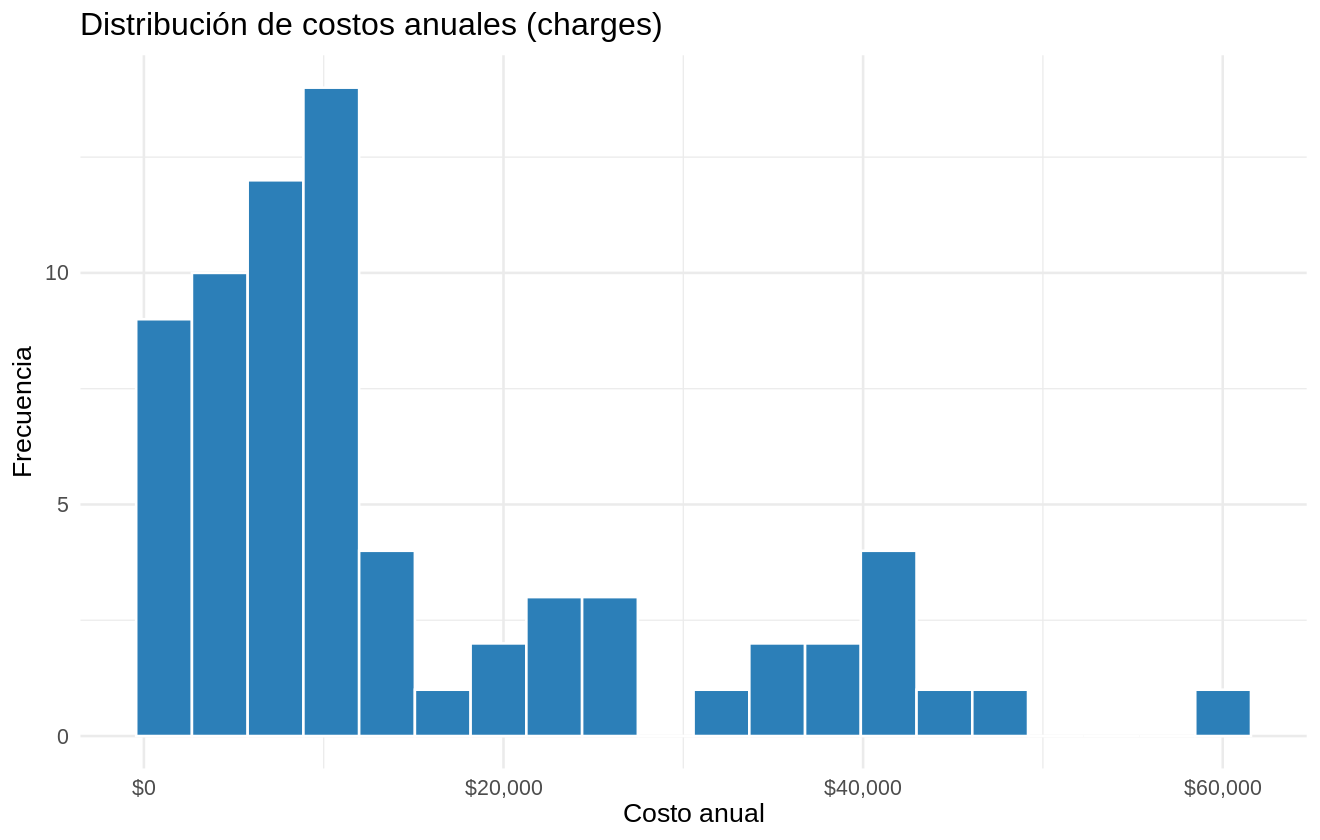

`geom_smooth()` using formula = 'y ~ x'


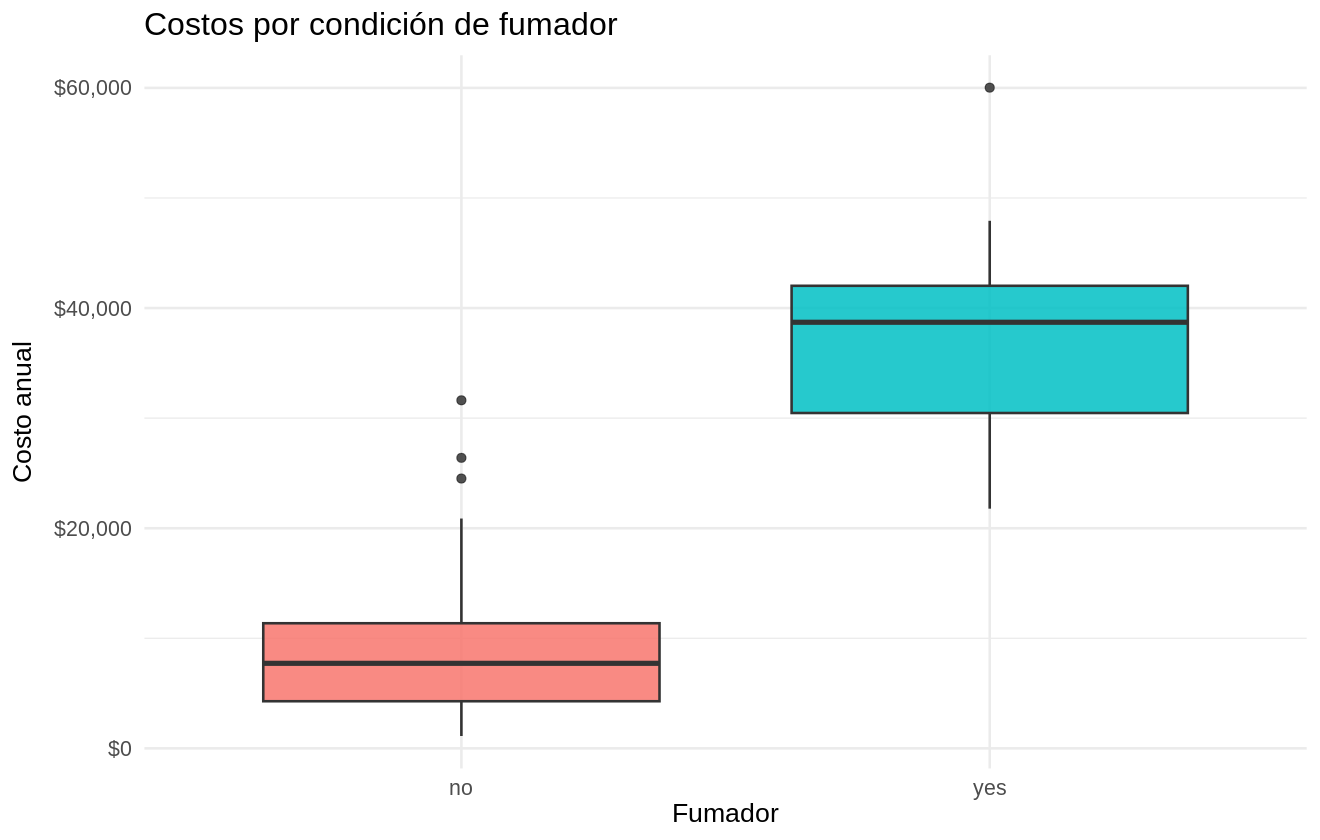

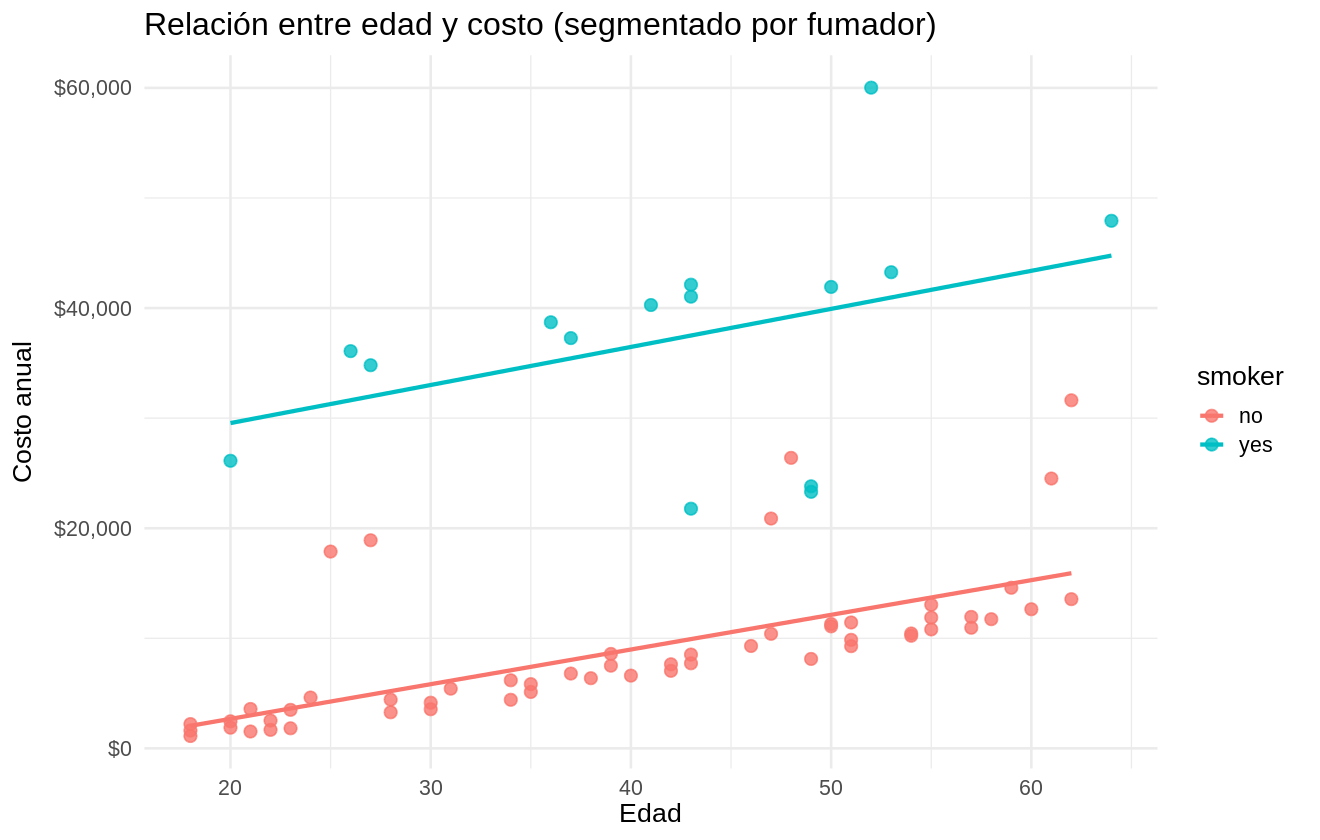

In [20]:
# Distribución de costos
p1 <- ggplot(sample_70_etiquetada, aes(x = costo_anual)) +
  geom_histogram(fill = "#2C7FB8", color = "white", bins = 20) +
  scale_x_continuous(labels = dollar_format(prefix = "$", big.mark = ",")) +
  labs(
    title = "Distribución del costo anual del seguro",
    x = "Costo anual (USD)",
    y = "Frecuencia"
  )

# Costos por condición de fumador
p2 <- ggplot(sample_70_etiquetada, aes(x = fumador, y = costo_anual, fill = fumador)) +
  geom_boxplot(alpha = 0.85) +
  scale_y_continuous(labels = dollar_format(prefix = "$", big.mark = ",")) +
  labs(
    title = "Costo anual según condición de fumador",
    x = "Condición de fumador",
    y = "Costo anual (USD)"
  ) +
  guides(fill = "none")

# Relación edad-costo
p3 <- ggplot(sample_70_etiquetada, aes(x = edad, y = costo_anual, color = fumador)) +
  geom_point(size = 3, alpha = 0.8) +
  geom_smooth(method = "lm", se = FALSE, linewidth = 1.2) +
  scale_y_continuous(labels = dollar_format(prefix = "$", big.mark = ",")) +
  labs(
    title = "Relación entre edad y costo anual por tabaquismo",
    x = "Edad (años)",
    y = "Costo anual (USD)",
    color = "Fumador"
  )

ruta_p1 <- file.path(output_dir, "histograma_costo_anual.png")
ruta_p2 <- file.path(output_dir, "boxplot_costo_por_fumador.png")
ruta_p3 <- file.path(output_dir, "dispersion_edad_costo_anual.png")

ggsave(filename = ruta_p1, plot = p1, width = 10, height = 6, dpi = 320, bg = "white")
ggsave(filename = ruta_p2, plot = p2, width = 10, height = 6, dpi = 320, bg = "white")
ggsave(filename = ruta_p3, plot = p3, width = 10, height = 6, dpi = 320, bg = "white")

print(p1)
print(p2)
print(p3)


### Interpretación descriptiva

1. La variable `charges` suele presentar asimetría positiva (costos altos concentrados en una fracción de personas).
2. Los fumadores tienden a mostrar costos notablemente superiores frente a no fumadores.
3. Existe una tendencia creciente entre edad y costo, más marcada dentro del grupo fumador.
4. El análisis descriptivo ya sugiere diferencias de grupos y relaciones lineales que luego se contrastan formalmente con pruebas inferenciales.

## 5) Pruebas de hipótesis

Se aplican varias pruebas para cubrir normalidad, independencia, comparación de grupos y asociación no paramétrica/paramétrica, con nivel de significancia $\alpha = 0.05$.

In [21]:
alpha <- 0.05

# 5.1 Normalidad del costo anual
shapiro_costo <- shapiro.test(sample_70_etiquetada$costo_anual)
shapiro_costo

# 5.2 Independencia: sexo vs condición de fumador
tabla_sexo_fumador <- table(sample_70_etiquetada$sexo, sample_70_etiquetada$fumador)
chi_sexo_fumador <- chisq.test(tabla_sexo_fumador)

tabla_sexo_fumador
chi_sexo_fumador

# 5.3 Diferencia de medias independientes (t-test): IMC por sexo
t_imc_sexo <- t.test(imc ~ sexo, data = sample_70_etiquetada, var.equal = FALSE)
t_imc_sexo

# 5.4 Prueba no paramétrica Mann-Whitney: costo anual por fumador
wilcox_costo_fumador <- wilcox.test(costo_anual ~ fumador, data = sample_70_etiquetada, exact = FALSE)
wilcox_costo_fumador



	Shapiro-Wilk normality test

data:  sample_70$charges
W = 0.82673, p-value = 1.322e-07


        
         no yes
  female 34   4
  male   21  11


	Pearson's Chi-squared test with Yates' continuity correction

data:  tabla_sex_smoker
X-squared = 4.5372, df = 1, p-value = 0.03317



	Welch Two Sample t-test

data:  bmi by sex
t = -0.16483, df = 65.572, p-value = 0.8696
alternative hypothesis: true difference in means between group female and group male is not equal to 0
95 percent confidence interval:
 -2.499524  2.118339
sample estimates:
mean in group female   mean in group male 
            31.30316             31.49375 



	Wilcoxon rank sum test with continuity correction

data:  charges by smoker
W = 11, p-value = 9.492e-09
alternative hypothesis: true location shift is not equal to 0


### Interpretación inferencial de las pruebas

- **Shapiro-Wilk (`charges`)**: permite evaluar si la distribución de costos se aproxima a normalidad.
- **Chi-cuadrado (`sex` vs `smoker`)**: identifica si existe dependencia entre ambas variables cualitativas.
- **t-test (`bmi` por `sex`)**: contrasta diferencia de medias de IMC entre grupos de sexo.
- **Mann-Whitney (`charges` por `smoker`)**: compara distribuciones de costos entre fumadores y no fumadores sin asumir normalidad.

La decisión se toma con p-valor: si \(p < 0.05\), se rechaza \(H_0\) y se concluye evidencia estadísticamente significativa.

## 6) Correlación y regresión lineal múltiple

Se ajusta un modelo donde `charges` es la variable respuesta y los predictores incluyen:

- Cuantitativos: `age`, `bmi`, `children`
- Cualitativos: `smoker`, `sex`, `region`

Esto permite estimar el efecto parcial de cada variable sobre el costo esperado, controlando por las demás.

In [22]:
# Correlación de Pearson entre variables numéricas principales
corr_mat <- cor(sample_70_etiquetada %>% select(edad, imc, hijos, costo_anual))
kable(round(corr_mat, 3))

# Modelo de regresión múltiple
modelo <- lm(charges ~ age + bmi + children + smoker + sex + region, data = sample_70)
summary(modelo)

# Tabla ordenada de coeficientes con etiquetas en español
coef_table <- broom::tidy(modelo, conf.int = TRUE) %>%
  mutate(
    termino = recode(
      term,
      `(Intercept)` = "Intercepto",
      age = "Edad",
      bmi = "IMC",
      children = "Número de hijos",
      smokeryes = "Fumador (Sí)",
      sexmale = "Sexo (Hombre)",
      regionnorthwest = "Región (Noroeste)",
      regionsoutheast = "Región (Sureste)",
      regionsouthwest = "Región (Suroeste)"
    )
  ) %>%
  select(termino, estimate, std.error, statistic, p.value, conf.low, conf.high)

kable(
  coef_table,
  digits = 4,
  col.names = c("Término", "Estimación", "Error estándar", "Estadístico t", "Valor p", "IC 2.5%", "IC 97.5%")
)




|         |    age|    bmi| children| charges|
|:--------|------:|------:|--------:|-------:|
|age      |  1.000| -0.049|    0.141|   0.372|
|bmi      | -0.049|  1.000|   -0.078|   0.161|
|children |  0.141| -0.078|    1.000|   0.016|
|charges  |  0.372|  0.161|    0.016|   1.000|


Call:
lm(formula = charges ~ age + bmi + children + smoker + sex + 
    region, data = sample_70)

Residuals:
     Min       1Q   Median       3Q      Max 
-12881.5  -2312.3   -422.1   2044.3  19976.5 

Coefficients:
                 Estimate Std. Error t value Pr(>|t|)    
(Intercept)     -12071.39    5275.43  -2.288  0.02560 *  
age                322.98      50.24   6.429  2.2e-08 ***
bmi                379.96     138.56   2.742  0.00800 ** 
children           392.52     508.57   0.772  0.44320    
smokeryes        27743.07    1651.18  16.802  < 2e-16 ***
sexmale          -1582.95    1360.86  -1.163  0.24928    
regionnorthwest  -5119.10    1916.69  -2.671  0.00969 ** 
regionsoutheast  -3728.34    1845.25  -2.021  0.04773 *  
regionsouthwest  -5627.17    1872.51  -3.005  0.00385 ** 
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 5380 on 61 degrees of freedom
Multiple R-squared:  0.866,	Adjusted R-squared:  0.8485 
F-statistic: 49.29 on 



|term            |    estimate| std.error| statistic| p.value|    conf.low|  conf.high|
|:---------------|-----------:|---------:|---------:|-------:|-----------:|----------:|
|(Intercept)     | -12071.3947| 5275.4263|   -2.2882|  0.0256| -22620.2616| -1522.5278|
|age             |    322.9794|   50.2374|    6.4291|  0.0000|    222.5234|   423.4354|
|bmi             |    379.9559|  138.5582|    2.7422|  0.0080|    102.8918|   657.0201|
|children        |    392.5222|  508.5693|    0.7718|  0.4432|   -624.4250|  1409.4694|
|smokeryes       |  27743.0682| 1651.1800|   16.8020|  0.0000|  24441.3297| 31044.8067|
|sexmale         |  -1582.9498| 1360.8623|   -1.1632|  0.2493|  -4304.1621|  1138.2625|
|regionnorthwest |  -5119.1008| 1916.6852|   -2.6708|  0.0097|  -8951.7496| -1286.4519|
|regionsoutheast |  -3728.3396| 1845.2489|   -2.0205|  0.0477|  -7418.1427|   -38.5364|
|regionsouthwest |  -5627.1666| 1872.5129|   -3.0051|  0.0038|  -9371.4876| -1882.8457|

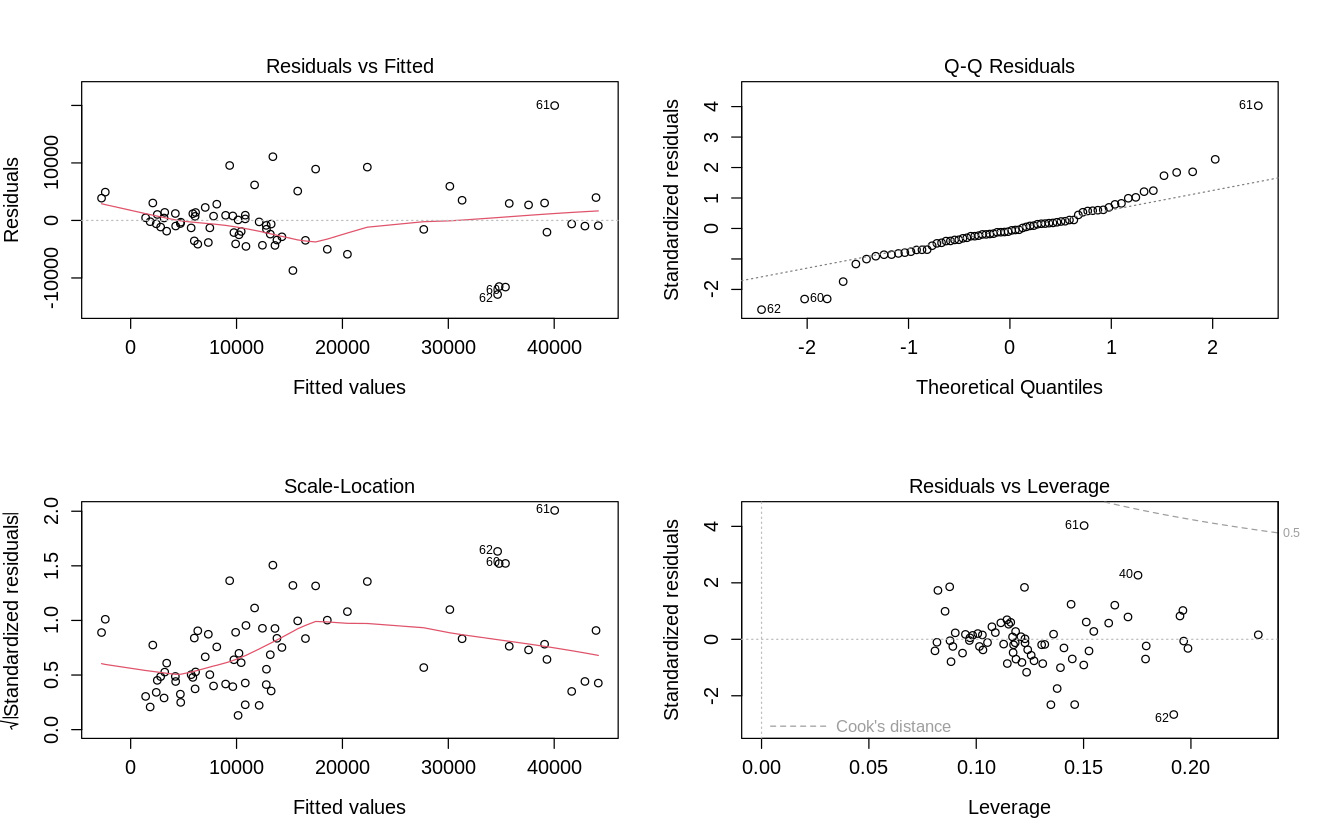

In [23]:
# Diagnóstico gráfico de supuestos
ruta_diag <- file.path(output_dir, "diagnostico_modelo_regresion.png")
png(filename = ruta_diag, width = 3200, height = 2600, res = 320)
par(mfrow = c(2, 2), cex.axis = 1.4, cex.lab = 1.6, cex.main = 1.5, mar = c(5, 5, 4, 2) + 0.1)
plot(modelo)
dev.off()
par(mfrow = c(1, 1))

knitr::include_graphics(ruta_diag)


### Lectura del modelo

Al interpretar los coeficientes:

1. El parámetro de `smoker` suele tener el impacto positivo más fuerte en los costos.
2. `age` también suele incrementar el costo esperado, manteniendo lo demás constante.
3. El ajuste global se revisa con $R^2$ y $R^2$ ajustado.
4. Los supuestos (linealidad, normalidad de residuos, homocedasticidad e independencia) se evalúan con gráficos diagnósticos.

Si algún supuesto no se cumple bien, se recomienda en un trabajo posterior explorar transformaciones (por ejemplo `log(charges)`) o modelos robustos.

## 7) Inferencia y predicción

Para ilustrar uso práctico del modelo, se generan predicciones para perfiles hipotéticos de personas con distintas características.

In [24]:
new_cases <- data.frame(
  age = c(25, 45, 60),
  bmi = c(24, 30, 33),
  children = c(0, 2, 3),
  smoker = factor(c("no", "yes", "no"), levels = levels(sample_70$smoker)),
  sex = factor(c("female", "male", "female"), levels = levels(sample_70$sex)),
  region = factor(c("northwest", "southeast", "northeast"), levels = levels(sample_70$region))
)

pred <- predict(modelo, newdata = new_cases, interval = "prediction", level = 0.95)
resultado_pred <- cbind(new_cases, as.data.frame(pred)) %>%
  mutate(
    smoker = ifelse(smoker == "yes", "Sí", "No"),
    sex = ifelse(sex == "female", "Mujer", "Hombre"),
    region = recode(
      as.character(region),
      northeast = "Noreste",
      northwest = "Noroeste",
      southeast = "Sureste",
      southwest = "Suroeste"
    )
  ) %>%
  rename(
    edad = age,
    imc = bmi,
    hijos = children,
    fumador = smoker,
    sexo = sex,
    prediccion = fit,
    limite_inferior = lwr,
    limite_superior = upr
  )

kable(resultado_pred, digits = 2)




| age| bmi| children|smoker |sex    |region    |      fit|       lwr|      upr|
|---:|---:|--------:|:------|:------|:---------|--------:|---------:|--------:|
|  25|  24|        0|no     |female |northwest |     2.93| -11509.87| 11515.74|
|  45|  30|        2|yes    |male   |southeast | 37078.18|  25714.43| 48441.93|
|  60|  33|        3|no     |female |northeast | 21023.48|   9604.75| 32442.21|

### Comentario de predicción

El intervalo de predicción (lwr, upr) es más amplio que un intervalo de confianza de la media, porque incorpora variabilidad individual. Esto es útil en contextos de planeación financiera en salud: el modelo entrega una estimación central del costo esperado, pero también un rango de incertidumbre para decisiones de presupuesto.

## 8) Conclusiones

1. El procedimiento de muestreo estratificado proporcional permitió trabajar con 70 observaciones manteniendo la representatividad de subgrupos relevantes.
2. El costo anual en salud (`charges`) presenta alta variabilidad y tendencia asimétrica.
3. Ser fumador se asocia con incrementos importantes en costos médicos, tanto descriptiva como inferencialmente.
4. La regresión múltiple permite cuantificar el efecto parcial de edad, IMC, hijos y variables categóricas sobre el gasto esperado.
5. El enfoque inferencial aplicado es útil para soporte de decisiones en costos y presupuestos de salud.

## 9) Recomendación de otros dos datasets para la misma actividad

1. **Medical Expenditure Panel Survey (MEPS)**  
   Enfocado en gasto médico, uso de servicios de salud y características socioeconómicas. Muy útil para inferencia en administración en salud y presupuestos.

2. **Hospital Cost Reports (CMS, EE. UU.)**  
   Reportes de costos hospitalarios con múltiples dimensiones financieras y operativas. Ideal para análisis de costos, comparación entre instituciones y modelado econométrico.